### 1: Hierarchical Clustering pada Dataset Sederhana

Pada cell ini dilakukan pengelompokan hierarki (*Hierarchical Clustering*) menggunakan dataset sederhana bertipe 2 dimensi:
1. **Mengimpor pustaka**: Memuat numpy, pandas, scipy, dan matplotlib.
2. **Inisialisasi Data**: Mengisi 6 pasangan titik ($a, b, c, d, e, f$).
3. **Matriks Jarak (*Distance Matrix*)**: Menghitung jarak Euclidean antartitik menggunakan pdist dan menampilkannya dalam tabel DataFrame.
4. **Klasterisasi Hierarki**: Mengelompokkan data menggunakan metode **Single Linkage** (jarak terdekat antar klaster).
5. **Visualisasi Dendrogram**: Menampilkan diagram hierarki (*dendrogram*) untuk melihat tahapan penggabungan tiap titik data.

=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


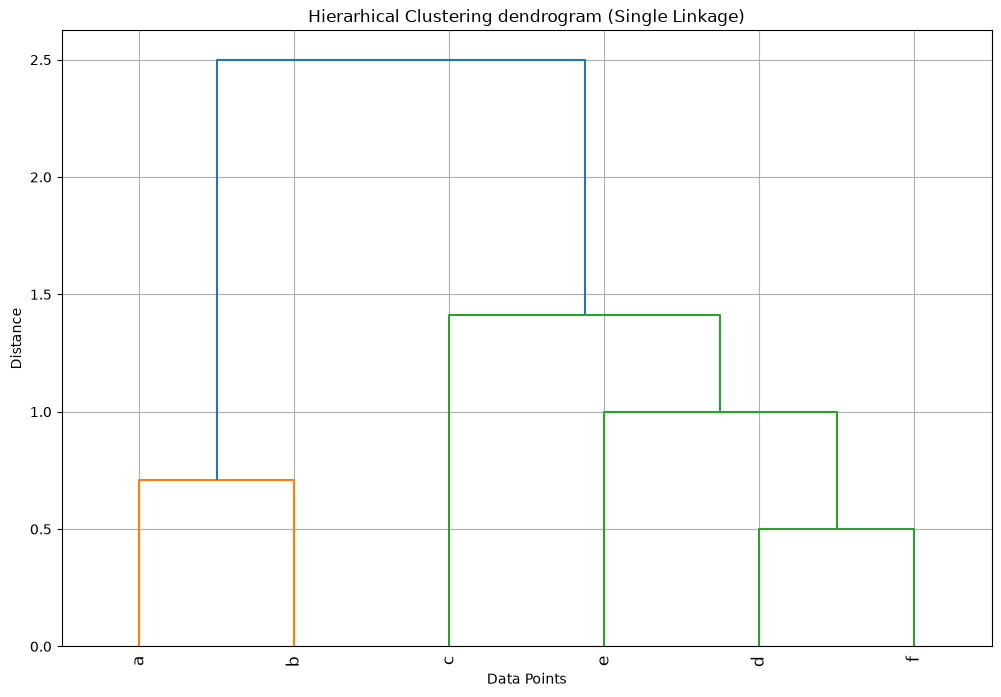

In [4]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# 1. Dataset sederhana
data = np.array([
    [1.0, 1.0], # a
    [1.5, 1.5], # b
    [5.0, 5.0], # c
    [3.0, 4.0], # d
    [4.0, 4.0], # e
    [3.0, 3.5]  # f
])

# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix), 
                           columns=['a', 'b', 'c', 'd', 'e', 'f'], 
                           index=['a', 'b', 'c', 'd', 'e', 'f'])

# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)

# 4. Hierarchical Clustering (Single Linkage)
linked = linkage(distance_matrix, method='single')

# 5. Plot dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarhical Clustering dendrogram (Single Linkage)")
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

### 2: Memuat Dataset Mall Customers

Cell ini berfungsi untuk membaca berkas Mall_Customers.csv ke dalam bentuk DataFrame menggunakan pustaka Pandas, lalu menampilkan 5 baris pertama data untuk memeriksa struktur kolom seperti CustomerID, Genre, Age, Annual Income (k$), dan Spending Score (1-100)[cite: 3].

In [5]:
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 3: Ekstraksi Fitur Utama

Pada cell ini, dilakukan seleksi variabel yang akan digunakan untuk klasterisasi[cite: 3]. Kita mengambil nilai dari kolom indeks ke-3 (Annual Income) dan indeks ke-4 (Spending Score)[cite: 3] lalu menyimpannya ke dalam variabel x berupa array NumPy.

In [6]:
x = df.iloc[:, [3, 4]].values

### 4: Standarisasi Data (*Feature Scaling*)

Cell ini melakukan proses pembakuan skala data menggunakan StandardScaler dari Scikit-Learn:
* Mengubah skala fitur agar memiliki rata-rata $0$ dan standar deviasi $1$, sehingga jarak antarvariabel dapat dihitung secara setara.
* Properti scaled_data.shape diperiksa untuk memastikan jumlah baris dan kolom hasil transformasi ($200$ sampel, $2$ fitur)[cite: 3].

In [7]:
from sklearn.preprocessing import StandardScaler

data_scaler = StandardScaler()

scaled_data = data_scaler.fit_transform(x)
scaled_data.shape

(200, 2)

### 5: Pembentukan Klaster Hierarki (Complete Linkage)

Pada cell ini dilakukan klasterisasi hierarki pada data Mall Customers yang telah di-skala:
* Menggunakan fungsi linkage dengan metode **Complete Linkage** (mengukur jarak maksimum antaranggota klaster)[cite: 3].
* Menghitung matriks jarak berdasarkan **Euclidean Distance**[cite: 3].

In [9]:
from scipy.cluster.hierarchy import linkage, dendrogram

clustering = linkage(scaled_data, method="complete", metric="euclidean")

### 6: Visualisasi Dendrogram Mall Customers

Cell ini menampilkan plot dendrogram dari objek clustering yang sudah dibuat[cite: 3]. Visualisasi ini memperlihatkan struktur pengelompokan pelanggan berdasarkan pendapatan dan skor pengeluaran mereka[cite: 3, 4].

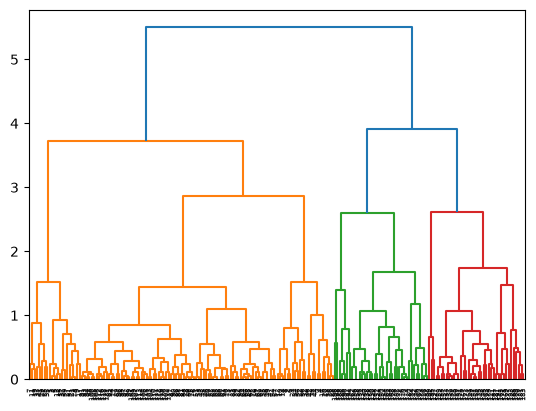

In [10]:
import matplotlib.pyplot as plt

dendrogram(clustering)
plt.show()

## Tugas: Perbandingan Single, Complete, dan Average Linkage

Pada tugas ini, kita membandingkan hasil klasterisasi hierarki pada dataset sederhana (titik $a$ sampai $f$) menggunakan tiga metode *linkage* yang berbeda:
1. **Single Linkage**: Mengukur jarak antar-klaster berdasarkan pasangan titik **terdekat** (*minimum distance*).
2. **Complete Linkage**: Mengukur jarak antar-klaster berdasarkan pasangan titik **terjauh** (*maximum distance*).
3. **Average Linkage**: Mengukur jarak antar-klaster berdasarkan **rata-rata jarak** dari seluruh pasangan titik.

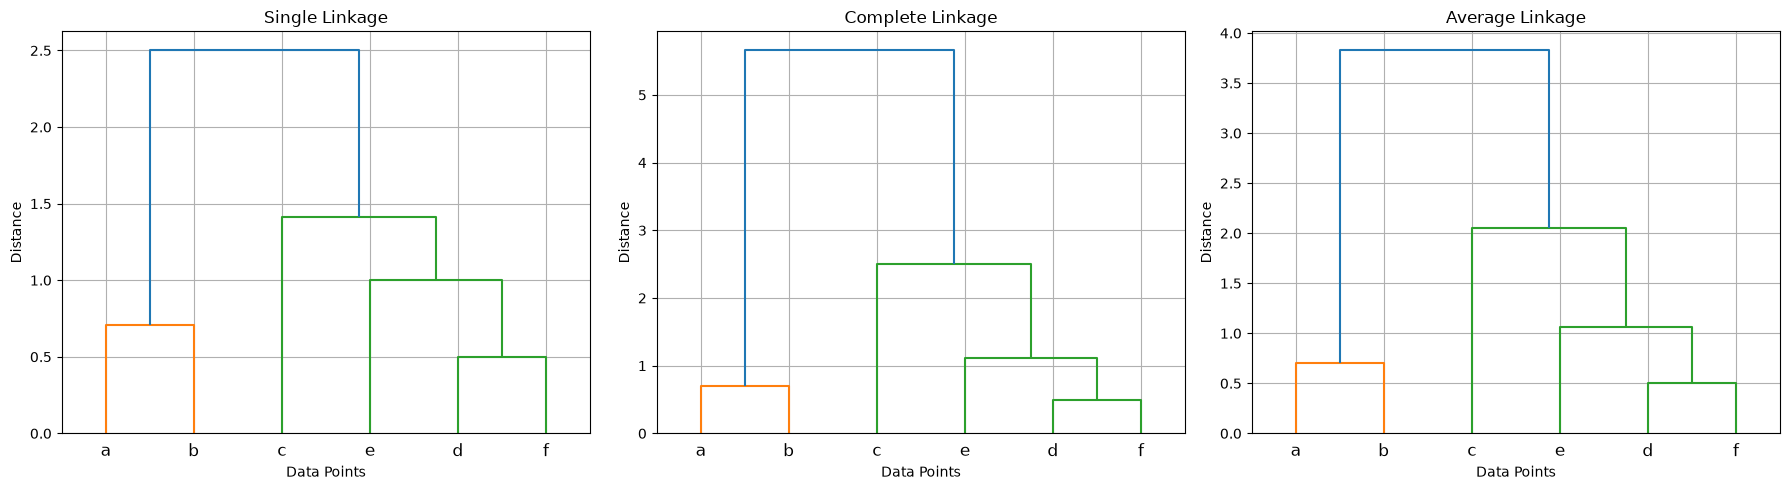

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# 1. Inisialisasi dataset sederhana
data = np.array([
    [1.0, 1.0],  # a
    [1.5, 1.5],  # b
    [5.0, 5.0],  # c
    [3.0, 4.0],  # d
    [4.0, 4.0],  # e
    [3.0, 3.5]   # f
])

labels = ['a', 'b', 'c', 'd', 'e', 'f']

# 2. Hitung linkage untuk ketiga metode
linked_single = linkage(data, method='single', metric='euclidean')
linked_complete = linkage(data, method='complete', metric='euclidean')
linked_average = linkage(data, method='average', metric='euclidean')

# 3. Visualisasi perbandingan ketiga dendrogram dalam satu figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Single Linkage
dendrogram(linked_single, labels=labels, ax=axes[0])
axes[0].set_title("Single Linkage")
axes[0].set_xlabel("Data Points")
axes[0].set_ylabel("Distance")
axes[0].grid(True)

# Plot Complete Linkage
dendrogram(linked_complete, labels=labels, ax=axes[1])
axes[1].set_title("Complete Linkage")
axes[1].set_xlabel("Data Points")
axes[1].set_ylabel("Distance")
axes[1].grid(True)

# Plot Average Linkage
dendrogram(linked_average, labels=labels, ax=axes[2])
axes[2].set_title("Average Linkage")
axes[2].set_xlabel("Data Points")
axes[2].set_ylabel("Distance")
axes[2].grid(True)

plt.tight_layout()
plt.show()

### Pembahasan Hasil Perbandingan

Dari ketiga dendrogram yang dihasilkan, dapat ditarik beberapa poin analisis:

* **Kesamaan Langkah Awal**:
  * Ketiga metode sama-sama menggabungkan titik **d** dan **f** terlebih dahulu pada tingkat jarak terkecil ($0.5$), diikuti oleh pasangan **a** dan **b** pada jarak $0.707$.
* **Perbedaan Ketinggian Garis (*Distance Height*)**:
  * **Single Linkage**: Garis penggabungan antar-klaster relatif rendah karena selalu menggunakan jarak terdekat antar-anggota klaster.
  * **Complete Linkage**: Garis penggabungan menjadi lebih tinggi saat klaster-klaster membesar karena memperhitungkan jarak paling jauh.
  * **Average Linkage**: Ketinggian garis berada di antara Single dan Complete Linkage karena menghitung rata-rata jarak seluruh anggota klaster.
* **Karakteristik Pengelompokan**:
  * Single Linkage cenderung memperlihatkan efek rantai (*chaining effect*).
  * Complete dan Average Linkage menghasilkan batas klaster yang lebih tegas dan seimbang.